## Project: Predicting CO₂ Emissions of Indian Cities

This notebook uses the CDP dataset to predict CO₂ emissions for Indian cities. It includes data preprocessing, feature engineering, regression modeling using XGBoost, and clustering to analyze city profiles.


In [ ]:
import pandas as pd

In [ ]:
file_path = "2023 CO2 emission dataset.xlsx"
xls = pd.ExcelFile(file_path)

In [ ]:
df = xls.parse("Sheet1")

## Data Cleaning and Preparation

We filter the dataset to include only Indian cities and remove irrelevant columns to focus on key predictors for emissions.


In [ ]:
columns_to_drop = ["Organization Name", "Organization Number","Questionnaire","Last update","City Location","Emissions Estimated"]
df = df.drop(columns = columns_to_drop,errors="ignore")

In [ ]:
df = df[df['Country']=='India']

In [ ]:
df = df[df["Emissions Response Answer"].notna()]


In [ ]:
df = df[df["Emissions Row Name"].str.contains("Scope 1", na=False)]


In [ ]:
print("Cleaned dataset shape:", df.shape)
df.head()


Cleaned dataset shape: (18, 24)


,City,Country,CDP Region,Access,Number of times reporting,C40 City,GCoM City,Primary protocol/framework used to compile main inventory,Gases included in main inventory,Emissions Question Number,...,Emissions Row Name,Emissions Response Answer,Emissions Notation Key,Emissions Description,Emissions Data Group,Emissions Rank,Year covered by main inventory,Boundary of main inventory relative to jurisdiction boundary,Population in year covered by main inventory,Tool used to compile main inventory
11,Chennai,India,South Asia,public,7,True,False,Global Protocol for Community-Scale Greenhouse...,CH4; CO2,2.1b,...,Transportation â€“ Scope 1,2244453.00,NaN,0801 Transportation â€“ Scope 1,SectorTotal,2,2018,Same - covers entire jurisdiction and nothing ...,8500000,CIRIS
114,Chennai,India,South Asia,public,7,True,False,Global Protocol for Community-Scale Greenhouse...,CH4; CO2,2.1b,...,"Agriculture, Forestry and Land Use â€“ Scope 1",0.00,NaN,"1501 Agriculture, Forestry and Land Use â€“ Sc...",SectorTotal,0,2018,Same - covers entire jurisdiction and nothing ...,8500000,CIRIS
142,Bangalore,India,South Asia,public,8,True,False,Global Protocol for Community-Scale Greenhouse...,CH4; CO2; N2O,2.1b,...,Industrial Processes and Product Use â€“ Scope 1,0.00,NaN,1401 Industrial Processes and Product Use â€“ ...,SectorTotal,0,2019,Same - covers entire jurisdiction and nothing ...,11361635,CIRIS
193,Bangalore,India,South Asia,public,8,True,False,Global Protocol for Community-Scale Greenhouse...,CH4; CO2; N2O,2.1b,...,Total Scope 1 emissions (excluding generation ...,7571029.00,NaN,0101 Total Scope 1 emissions (excluding genera...,SourceTotal,2,2019,Same - covers entire jurisdiction and nothing ...,11361635,CIRIS
226,Delhi,India,South Asia,public,7,True,False,Regional or country/area specific methodology,HFCs; NF3; SF6,2.1b,...,Total Scope 1 emissions (excluding generation ...,21.53,NaN,0101 Total Scope 1 emissions (excluding genera...,SourceTotal,1,2021,Larger - covers the whole jurisdiction and adj...,3118100,"Other, please specify: Landsat-8 satellite da..."


## Feature Engineering

We prepare the dataset by selecting relevant features and transforming categorical variables using techniques like One-Hot Encoding. Numerical features are scaled where necessary. These processed features form the input to our predictive model and ensure that the model captures the underlying patterns effectively.


In [ ]:
features = ["Population in year covered by main inventory",
            "Primary protocol/framework used to compile main inventory",
            "Number of times reporting",
            "Tool used to compile main inventory"]

target = "Emissions Response Answer"

X = df[features]
y = df[target]


In [ ]:
# Fill missing values
X = X.fillna("Unknown")

# One-hot encode categorical features
X = pd.get_dummies(X)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
df.to_csv("Cleaned_CDP_Dataset.csv", index=False)

In [ ]:
from google.colab import files
files.download("Cleaned_CDP_Dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Prediction of CO₂ Emissions

We train a regression model using city-level features such as population, climate data, and infrastructure-related attributes to predict CO₂ emissions for cities with missing values. This enables better estimation of environmental impact where direct data is not available.


In [ ]:
import pandas as pd


df_cleaned = pd.read_csv("Cleaned_CDP_Dataset.csv")


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from math import sqrt

# Step 1: Define features and target
features = [
    "Population in year covered by main inventory",
    "Number of times reporting",
    "Primary protocol/framework used to compile main inventory",
    "Tool used to compile main inventory"
]
target = "Emissions Response Answer"

X = df_cleaned[features]
y = df_cleaned[target]

# Step 2: Define categorical columns
categorical_features = [
    "Primary protocol/framework used to compile main inventory",
    "Tool used to compile main inventory"
]

# Step 3: Preprocessing + XGBoost pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(random_state=42, n_estimators=100))
])

# Step 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 5: Train model
pipeline.fit(X_train, y_train)

# Step 6: Predict and evaluate
y_pred = pipeline.predict(X_test)
rmse = sqrt(mean_squared_error(y_test, y_pred))

# Show result
print("RMSE:", rmse)
for actual, pred in zip(y_test.values, y_pred):
    print(f"Actual: {actual:.0f}, Predicted: {pred:.0f}")


RMSE: 1395319.7531259868
Actual: 2244453, Predicted: 807408
Actual: 0, Predicted: 807408
Actual: 3777635, Predicted: 1564430
Actual: 1979627, Predicted: 1564430


<ipython-input-22-506912040>:48: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


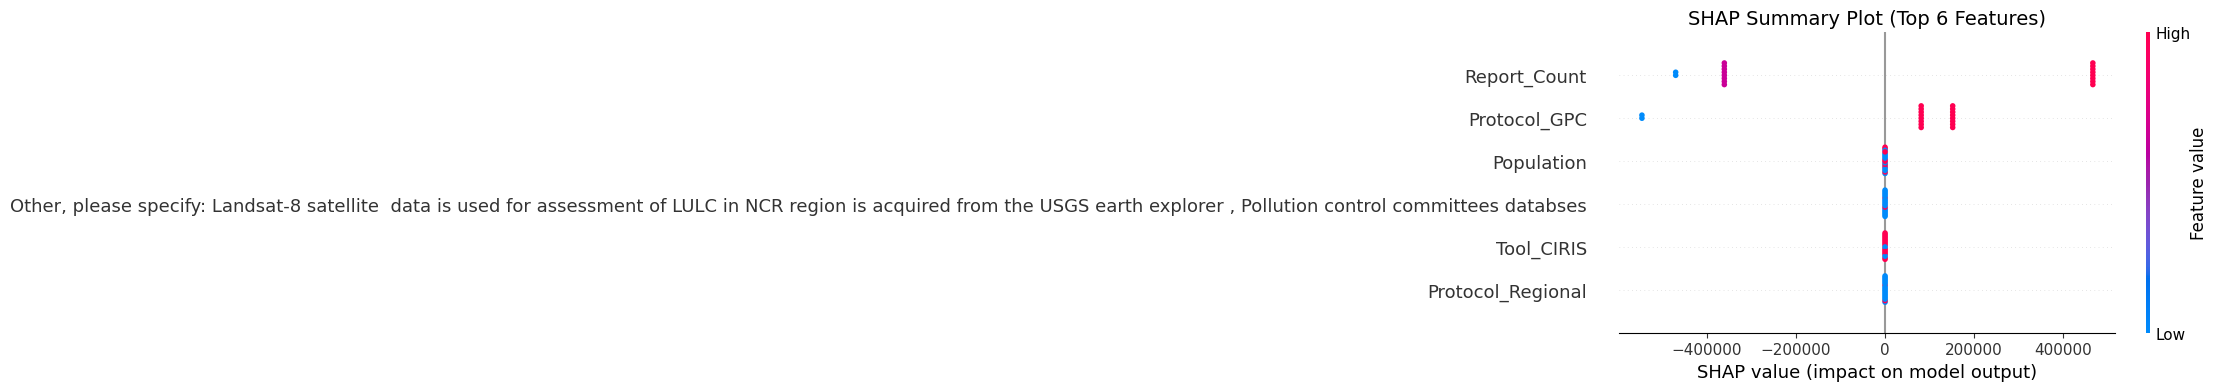

In [ ]:
# ✅ Prevent SHAP from using GPU (avoid CUDA error)
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

# Imports
import shap
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Define original categorical and numeric features
categorical_features = [
    "Primary protocol/framework used to compile main inventory",
    "Tool used to compile main inventory"
]
numeric_features = [
    "Number of times reporting",
    "Population in year covered by main inventory"
]

# Step 2: Get OneHotEncoder from pipeline and feature names
ohe = pipeline.named_steps["preprocessor"].named_transformers_["cat"]
encoded_feature_names = ohe.get_feature_names_out(categorical_features)

# Step 3: Custom mapping to clean long feature names
feature_name_map = {
    "Primary protocol/framework used to compile main inventory_Global Protocol for Community-Scale Greenhouse Gas Emissions Inventories (GPC)": "Protocol_GPC",
    "Primary protocol/framework used to compile main inventory_Regional or country/area specific methodology": "Protocol_Regional",
    "Tool used to compile main inventory_CIRIS": "Tool_CIRIS",
    "Tool used to compile main inventory_Other, please specify: Landsat-8 satellite  data is used for assessment of LULC in NCR region is acquired from the USGS earth explorer , Pollution control committees databases": "Tool_Landsat",
    # Add more if needed
}

# Step 4: Clean encoded names
clean_cat_names = [feature_name_map.get(name, name.split("_")[-1]) for name in encoded_feature_names]
final_feature_names = clean_cat_names + ["Report_Count", "Population"]

# Step 5: Transform X and create DataFrame with short names
X_transformed = pipeline.named_steps["preprocessor"].transform(X)
X_df = pd.DataFrame(X_transformed, columns=final_feature_names)

# Step 6: SHAP explanation
explainer = shap.Explainer(pipeline.named_steps["model"])
shap_values = explainer(X_df)

# Step 7: Generate SHAP summary plot
shap.plots.beeswarm(shap_values, max_display=6, show=False)
plt.title("SHAP Summary Plot (Top 6 Features)", fontsize=14)
plt.tight_layout()
plt.savefig("SHAP_summary_clean_final_fixed.png")
plt.show()


## Disclosure Score Calculation

To assess transparency, we define a 'Disclosure Score' based on whether the city has disclosed key environmental information such as emissions inventory, targets, and reduction activities. This score helps in evaluating how proactive each city is in climate reporting.


In [ ]:
import pandas as pd

# Load your uploaded cleaned dataset
df_cleaned = pd.read_csv("Cleaned_CDP_Dataset.csv")

# See all column names
print(df_cleaned.columns.tolist())

# Preview the first few rows
df_cleaned.head(3)


['City', 'Country', 'CDP Region', 'Access', 'Number of times reporting', 'C40 City', 'GCoM City', 'Primary protocol/framework used to compile main inventory', 'Gases included in main inventory', 'Emissions Question Number', 'Emissions Question Name', 'Emissions Column Number', 'Emissions Column Name', 'Emissions Row Number', 'Emissions Row Name', 'Emissions Response Answer', 'Emissions Notation Key', 'Emissions Description', 'Emissions Data Group', 'Emissions Rank', 'Year covered by main inventory', 'Boundary of main inventory relative to jurisdiction boundary', 'Population in year covered by main inventory', 'Tool used to compile main inventory']


,City,Country,CDP Region,Access,Number of times reporting,C40 City,GCoM City,Primary protocol/framework used to compile main inventory,Gases included in main inventory,Emissions Question Number,...,Emissions Row Name,Emissions Response Answer,Emissions Notation Key,Emissions Description,Emissions Data Group,Emissions Rank,Year covered by main inventory,Boundary of main inventory relative to jurisdiction boundary,Population in year covered by main inventory,Tool used to compile main inventory
0,Chennai,India,South Asia,public,7,True,False,Global Protocol for Community-Scale Greenhouse...,CH4; CO2,2.1b,...,Transportation â€“ Scope 1,2244453.0,NaN,0801 Transportation â€“ Scope 1,SectorTotal,2,2018,Same - covers entire jurisdiction and nothing ...,8500000,CIRIS
1,Chennai,India,South Asia,public,7,True,False,Global Protocol for Community-Scale Greenhouse...,CH4; CO2,2.1b,...,"Agriculture, Forestry and Land Use â€“ Scope 1",0.0,NaN,"1501 Agriculture, Forestry and Land Use â€“ Sc...",SectorTotal,0,2018,Same - covers entire jurisdiction and nothing ...,8500000,CIRIS
2,Bangalore,India,South Asia,public,8,True,False,Global Protocol for Community-Scale Greenhouse...,CH4; CO2; N2O,2.1b,...,Industrial Processes and Product Use â€“ Scope 1,0.0,NaN,1401 Industrial Processes and Product Use â€“ ...,SectorTotal,0,2019,Same - covers entire jurisdiction and nothing ...,11361635,CIRIS


In [ ]:
# Make a copy of the dataset
df = df_cleaned.copy()

# Define a helper to score each row
def score_disclosure(row):
    score = 0
    if pd.notna(row["Primary protocol/framework used to compile main inventory"]) and "unknown" not in row["Primary protocol/framework used to compile main inventory"].lower():
        score += 1
    if pd.notna(row["Tool used to compile main inventory"]) and "unknown" not in row["Tool used to compile main inventory"].lower():
        score += 1
    if pd.notna(row["Number of times reporting"]) and row["Number of times reporting"] >= 2:
        score += 1
    return score

# Apply to your DataFrame
df["Disclosure Score"] = df.apply(score_disclosure, axis=1)

# See how it looks
df[["City", "Disclosure Score", "Primary protocol/framework used to compile main inventory", "Tool used to compile main inventory", "Number of times reporting"]].head()


,City,Disclosure Score,Primary protocol/framework used to compile main inventory,Tool used to compile main inventory,Number of times reporting
0,Chennai,3,Global Protocol for Community-Scale Greenhouse...,CIRIS,7
1,Chennai,3,Global Protocol for Community-Scale Greenhouse...,CIRIS,7
2,Bangalore,3,Global Protocol for Community-Scale Greenhouse...,CIRIS,8
3,Bangalore,3,Global Protocol for Community-Scale Greenhouse...,CIRIS,8
4,Delhi,3,Regional or country/area specific methodology,"Other, please specify: Landsat-8 satellite da...",7


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Step 1: Select features and target
features = [
    "Population in year covered by main inventory",
    "Number of times reporting",
    "Primary protocol/framework used to compile main inventory",
    "Tool used to compile main inventory"
]
target = "Disclosure Score"

X = df[features]
y = df[target]

# Step 2: Define preprocessing
categorical_features = [
    "Primary protocol/framework used to compile main inventory",
    "Tool used to compile main inventory"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

# Step 3: Build pipeline
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(random_state=42, n_estimators=100))
])

# Step 4: Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 5: Train the model
pipeline.fit(X_train, y_train)

# Step 6: Evaluate
y_pred = pipeline.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE (Disclosure Score):", rmse)

# Print some predictions
for actual, pred in zip(y_test.values, y_pred):
    print(f"Actual: {actual}, Predicted: {pred:.2f}")


RMSE (Disclosure Score): 0.0
Actual: 3, Predicted: 3.00
Actual: 3, Predicted: 3.00
Actual: 3, Predicted: 3.00
Actual: 3, Predicted: 3.00


<ipython-input-26-2767973576>:32: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


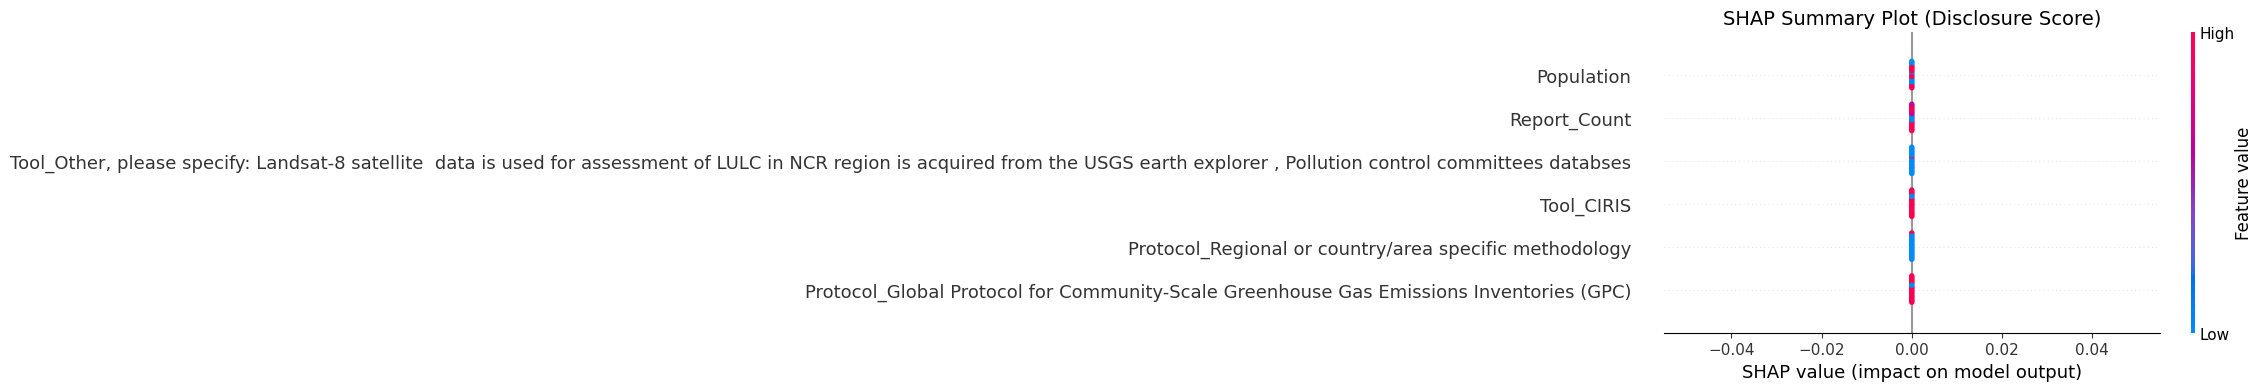

In [ ]:
import shap
import pandas as pd
import matplotlib.pyplot as plt

# Assuming you’ve already trained your pipeline and created df

# Step 1: Clean encoded feature names
ohe = pipeline.named_steps["preprocessor"].named_transformers_["cat"]
encoded_feature_names = ohe.get_feature_names_out([
    "Primary protocol/framework used to compile main inventory",
    "Tool used to compile main inventory"
])

clean_cat_names = [
    name.replace("Primary protocol/framework used to compile main inventory_", "Protocol_")
        .replace("Tool used to compile main inventory_", "Tool_")
        .replace("cat__", "") for name in encoded_feature_names
]
final_feature_names = clean_cat_names + ["Report_Count", "Population"]

# Step 2: Transform and create DataFrame for SHAP
X_transformed = pipeline.named_steps["preprocessor"].transform(X)
X_df = pd.DataFrame(X_transformed, columns=final_feature_names)

# Step 3: Run SHAP
explainer = shap.Explainer(pipeline.named_steps["model"])
shap_values = explainer(X_df)

# Step 4: Plot
shap.plots.beeswarm(shap_values, max_display=6, show=False)
plt.title("SHAP Summary Plot (Disclosure Score)", fontsize=14)
plt.tight_layout()
plt.savefig("SHAP_summary_disclosure_score.png")
plt.show()


## Clustering of Cities

We use KMeans and Hierarchical clustering to group cities by their emissions, population, and disclosure score.


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBRegressor

# Define the same features used earlier for emissions
emission_features = [
    "Population in year covered by main inventory",
    "Number of times reporting",
    "Primary protocol/framework used to compile main inventory",
    "Tool used to compile main inventory"
]
X_emissions = df[emission_features]
y_emissions = df["Emissions Response Answer"]

# Preprocessing
cat_features = [
    "Primary protocol/framework used to compile main inventory",
    "Tool used to compile main inventory"
]

preprocessor_emissions = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)],
    remainder="passthrough"
)

# Emissions pipeline
pipeline_emissions = Pipeline(steps=[
    ("preprocessor", preprocessor_emissions),
    ("model", XGBRegressor(random_state=42, n_estimators=100))
])

# Train the model again
pipeline_emissions.fit(X_emissions, y_emissions)


/usr/local/lib/python3.11/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Primary protocol/framework '
                                                   'used to compile main '
                                                   'inventory',
                                                   'Tool used to compile main '
                                                   'inventory'])])),
                ('model',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsam...
                              feature_types=None, gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=100, n_jobs=None,
                              num_parallel_tree=None, random_state=42, ...))])

In [ ]:
df_cluster = pd.DataFrame({
    "City": df["City"],
    "Predicted Emissions": pipeline_emissions.predict(X_emissions),
    "Disclosure Score": df["Disclosure Score"],
    "Population": df["Population in year covered by main inventory"]
})


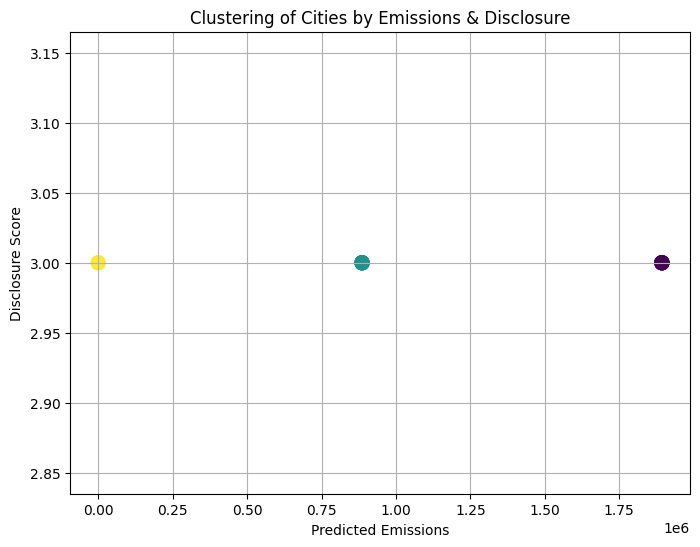

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Normalize data
features_for_clustering = ["Predicted Emissions", "Disclosure Score", "Population"]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster[features_for_clustering])

# Run KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
df_cluster["Cluster"] = kmeans.fit_predict(X_scaled)

# Plot
plt.figure(figsize=(8, 6))
scatter = plt.scatter(df_cluster["Predicted Emissions"], df_cluster["Disclosure Score"],
                      c=df_cluster["Cluster"], cmap="viridis", s=100, alpha=0.7)
plt.xlabel("Predicted Emissions")
plt.ylabel("Disclosure Score")
plt.title("Clustering of Cities by Emissions & Disclosure")
plt.grid(True)
plt.show()


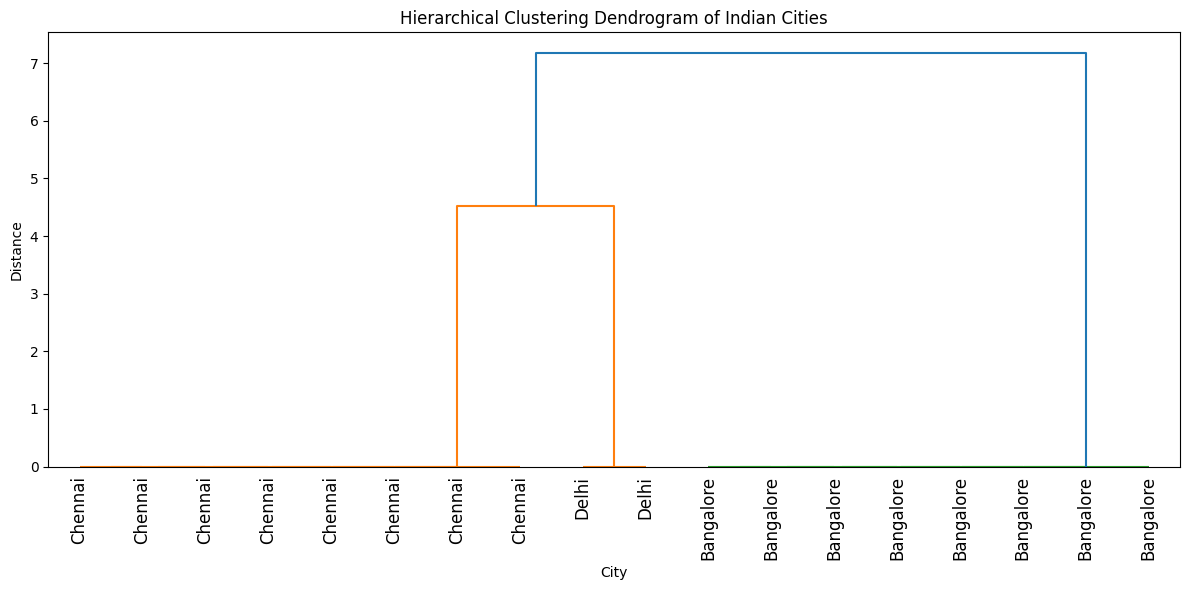

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# Step 1: Prepare the data (reuse from earlier)
df_cluster = pd.DataFrame({
    "City": df["City"],
    "Predicted Emissions": pipeline_emissions.predict(X_emissions),
    "Disclosure Score": df["Disclosure Score"],
    "Population": df["Population in year covered by main inventory"]
})

# Step 2: Normalize the features
features = ["Predicted Emissions", "Disclosure Score", "Population"]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster[features])

# Step 3: Generate linkage matrix (hierarchical clustering)
linked = linkage(X_scaled, method="ward")

# Step 4: Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linked,
           labels=df_cluster["City"].values,
           orientation="top",
           distance_sort="descending",
           show_leaf_counts=True)
plt.title("Hierarchical Clustering Dendrogram of Indian Cities")
plt.xlabel("City")
plt.ylabel("Distance")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


## Model Evaluation

We evaluate the model using standard regression metrics such as R², MAE, and RMSE.


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

y_pred = pipeline_emissions.predict(X_test)

print("R² Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))


R² Score: 0.0
MAE: 1389543.5
RMSE: 1477929.9713423501


## Visualizations: Actual vs. Predicted Emissions

We plot predicted vs. actual CO₂ emissions to visualize model performance.


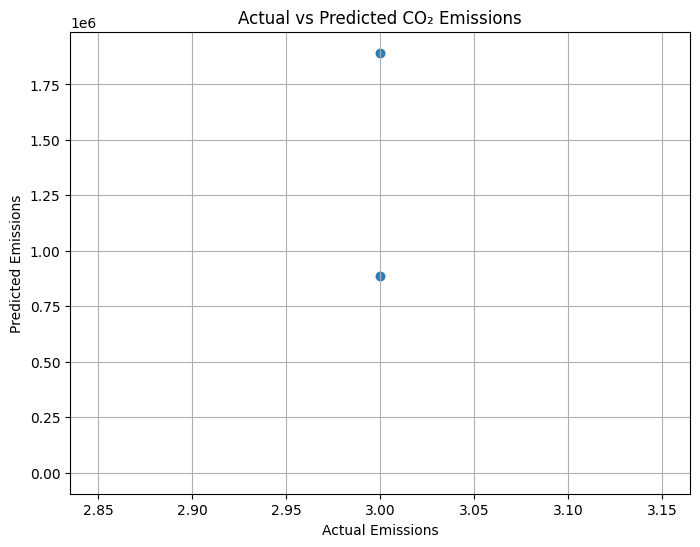

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Actual Emissions")
plt.ylabel("Predicted Emissions")
plt.title("Actual vs Predicted CO₂ Emissions")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.grid(True)
plt.show()
